In [19]:
import numpy as np

# Создаем тестовый сигнал с меняющейся ЧОТ
fs = 22050
duration = 0.1
t = np.linspace(0, duration, int(fs * duration))

f0_start = 175
f0_end = 275
f0 = np.linspace(f0_start, f0_end, len(t))
phase = np.cumsum(2 * np.pi * f0 / fs)
synthetic_speech = 0.5 * np.sin(phase)

# Добавляем гармоники
synthetic_speech += 0.25 * np.sin(2 * phase)
synthetic_speech += 0.125 * np.sin(3 * phase)
synthetic_speech += 0.15 * np.sin(4 * phase)

# + шум
synthetic_speech += 0.01 * np.random.randn(len(synthetic_speech))

print(len(synthetic_speech))

2205


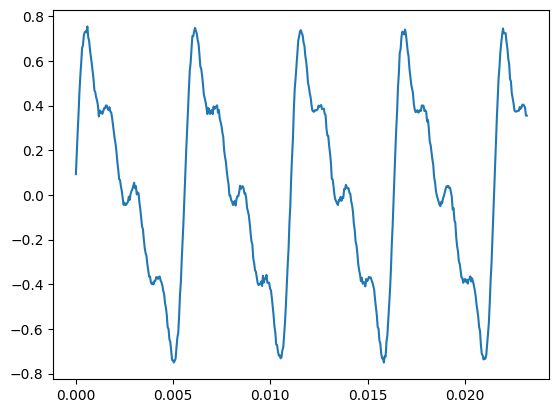

In [20]:
import matplotlib.pyplot as plt

plt.plot(t[:512], synthetic_speech[:512])

Сегментация: окнами считаем ЧОТ, добавляем период к первой границе

In [21]:
def autocorrelation(signal):
    """
    Вычисление автокорреляции сигнала
    """
    corr = np.correlate(signal, signal, mode='full')
    return corr[len(corr)//2:]

In [22]:
def find_pitch_period(frame, min_period, max_period):
    """
    Поиск периода ОТ на фрейме в отсчетах
    """
    # Вычисляем автокорреляцию
    corr = autocorrelation(frame)

    # Ищем максимум в допустимом диапазоне периодов
    search_start = min_period
    search_end = min(max_period, len(corr))

    if search_end <= search_start:
        return 0

    # Находим максимум автокорреляции
    search_region = corr[search_start:search_end]
    if len(search_region) == 0:
        return 0

    max_idx = np.argmax(search_region) + search_start

    # Проверяем, что найденный пик достаточно большой
    if corr[max_idx] > 0.3 * corr[0]:  # Порог 30% от автокорреляции при нулевой задержке
        return max_idx
    else:
        return 0

In [23]:
def segment(audio, fs, frame_size=0.02, hop_size=0.01, min_f0=50, max_f0=600):
    """
    Сегментация аудио на периоды основного тона

    """
    # Центрируем сигнал (убираем постоянную составляющую)
    signal = audio - np.mean(audio)

    frame_length = int(frame_size * fs)
    hop_length = int(hop_size * fs)

    boundaries = [0]  # Считаем, что первая граница в нуле
    periods = []

    pos = 0
    while pos + frame_length < len(audio):
        frame = audio[pos:pos + frame_length]

        # Находим период в текущем фрейме
        period = find_pitch_period(frame, fs//max_f0, fs//min_f0)
        print(pos/fs, fs//period)

        if period > 0:
            # Если нашли период, добавляем границу
            new_pos = pos + period
            if new_pos < len(audio) and new_pos > boundaries[-1]:
                boundaries.append(int(new_pos))
                periods.append(period)
                pos = new_pos  # Переходим к следующему периоду
            else:
                pos += hop_length
        else:
            # Если не нашли период (пауза или шум), двигаемся с заданным шагом
            pos += hop_length

    # Добавляем конец сигнала как последнюю границу
    if boundaries[-1] < len(audio):
        boundaries.append(len(audio))

    return np.array(boundaries), np.array(periods)

In [24]:
boundaries, periods = segment(synthetic_speech, fs, frame_size=0.01, hop_size=0.005)

0.0 179
0.005578231292517007 186
0.010929705215419501 193
0.016099773242630386 200
0.02108843537414966 204
0.02598639455782313 208
0.030793650793650793 212
0.035510204081632656 216
0.04013605442176871 220
0.04467120181405896 227
0.0490702947845805 232
0.05337868480725624 237
0.05759637188208617 239
0.0617687074829932 245
0.06585034013605442 247
0.06988662131519274 250
0.07387755102040816 256
0.07777777777777778 259
0.08163265306122448 262
0.0854421768707483 265
0.0892063492063492 268


In [25]:
boundaries

array([   0,  123,  241,  355,  465,  573,  679,  783,  885,  985, 1082,
       1177, 1270, 1362, 1452, 1541, 1629, 1715, 1800, 1884, 1967, 2049,
       2205])

In [26]:
periods

array([123, 118, 114, 110, 108, 106, 104, 102, 100,  97,  95,  93,  92,
        90,  89,  88,  86,  85,  84,  83,  82])

In [27]:
def visualize(audio, boundaries, fs):
    time = np.arange(len(audio)) / fs

    plt.figure(figsize=(15, 8))

    plt.plot(time, audio, 'b-', linewidth=0.8, alpha=0.7)

    # Отмечаем границы периодов
    for b in boundaries:
        if b/fs < time[-1]:
            plt.axvline(x=b/fs, color='r', linestyle='--', alpha=0.5)

    plt.title('Результат сегментации')
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.grid(True)

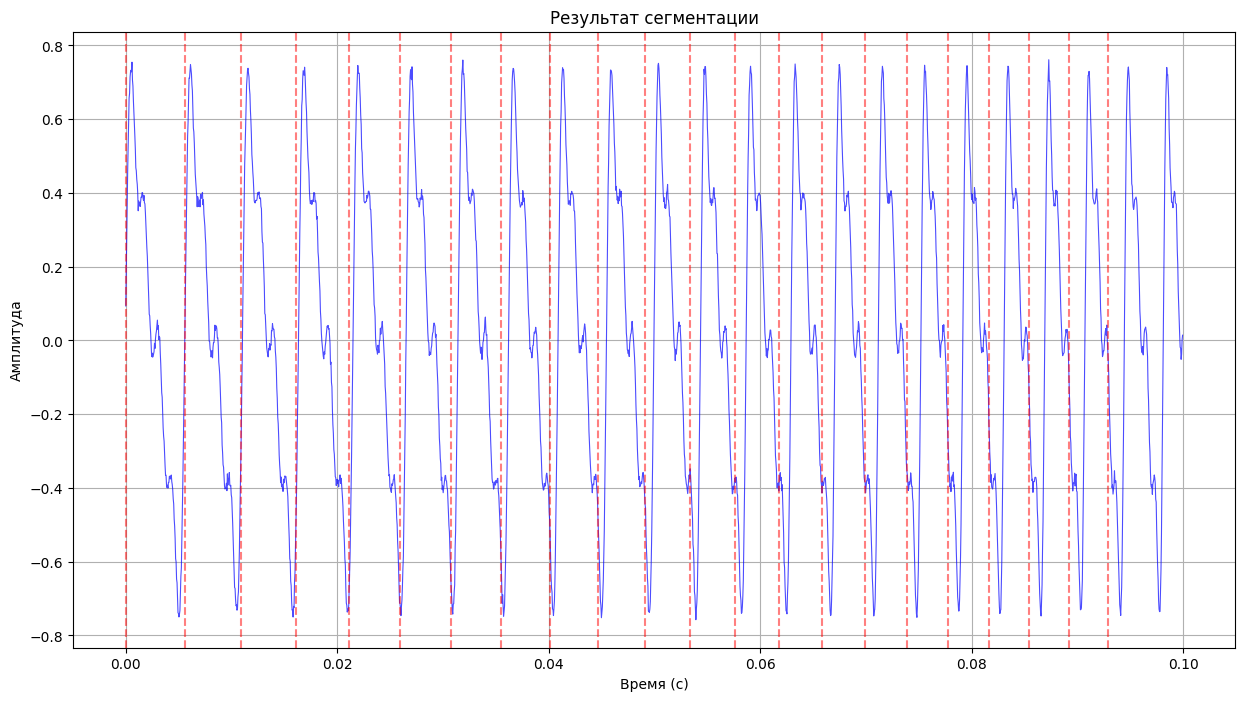

In [28]:
visualize(synthetic_speech, boundaries, fs)

Попробуем корректировать каждую новую границу по ближайшему нулю:

In [29]:
def nearest(lst, target):
    """
    Находит ближайшую точку к значению target из списка lst

    """
    if len(lst) == 0:
        return 0
    return min(lst, key=lambda x: abs(x - target))

In [30]:
def segment_with_zero_crossings(audio, fs, frame_size=0.02, hop_size=0.01, min_f0=50, max_f0=600):
    """
    Сегментация аудио на периоды основного тона

    """
    # Центрируем сигнал (убираем постоянную составляющую)
    audio = audio - np.mean(audio)

    frame_length = int(frame_size * fs)
    hop_length = int(hop_size * fs)

    boundaries = [0]  # Считаем, что первая граница в нуле
    periods = []

    # Переходы через ноль в сигнале
    zero_crossings = np.where(np.diff(np.sign(audio)))[0]

    # Добавим нули в конец сигнала, чтобы разметить периоды в последнем окне
    audio = np.concatenate((audio, np.zeros(int(frame_size * fs))))

    pos = 0
    while pos + frame_length < len(audio):
        frame = audio[pos:pos + frame_length]

        # Находим период в текущем фрейме
        period = find_pitch_period(frame, fs//max_f0, fs//min_f0)

        if period > 0:
            # Если нашли период, добавляем границу
            new_pos = pos + period
            if new_pos < len(audio) and new_pos > boundaries[-1]:
                new_pos_corrected = nearest(zero_crossings, new_pos)
                boundaries.append(int(new_pos_corrected))
                periods.append(period)
                pos = new_pos_corrected  # Переходим к следующему периоду
            else:
                pos += hop_length
        else:
            # Если не нашли период (пауза или шум), двигаемся с заданным шагом
            pos += hop_length

    # Добавляем конец сигнала как последнюю границу
    if boundaries[-1] < len(audio):
        boundaries.append(len(audio))

    return np.array(boundaries), np.array(periods)

In [31]:
boundaries, periods = segment_with_zero_crossings(synthetic_speech, fs, frame_size=0.01, hop_size=0.005)

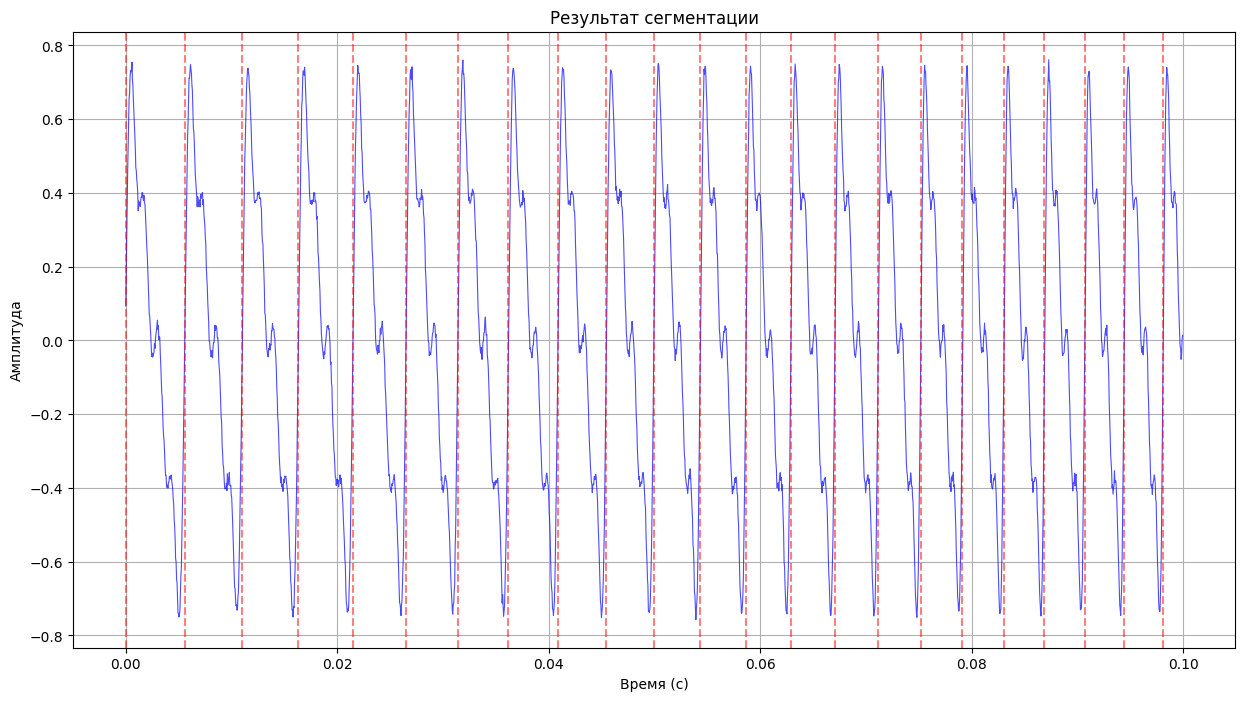

In [32]:
visualize(synthetic_speech, boundaries, fs)

Попробуем алгоритм на реальном сигнале

In [33]:
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/ju.wav

--2026-03-03 13:05:05--  https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/ju.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12752 (12K) [audio/wav]
Saving to: ‘ju.wav.1’

ju.wav.1            100%[===================>]  12.45K  --.-KB/s    in 0.001s  

2026-03-03 13:05:05 (23.0 MB/s) - ‘ju.wav.1’ saved [12752/12752]



In [34]:
from scipy.io import wavfile

fs, data = wavfile.read(r"ju.wav")

In [35]:
boundaries, periods = segment_with_zero_crossings(data, fs, frame_size=0.01, hop_size=0.005)

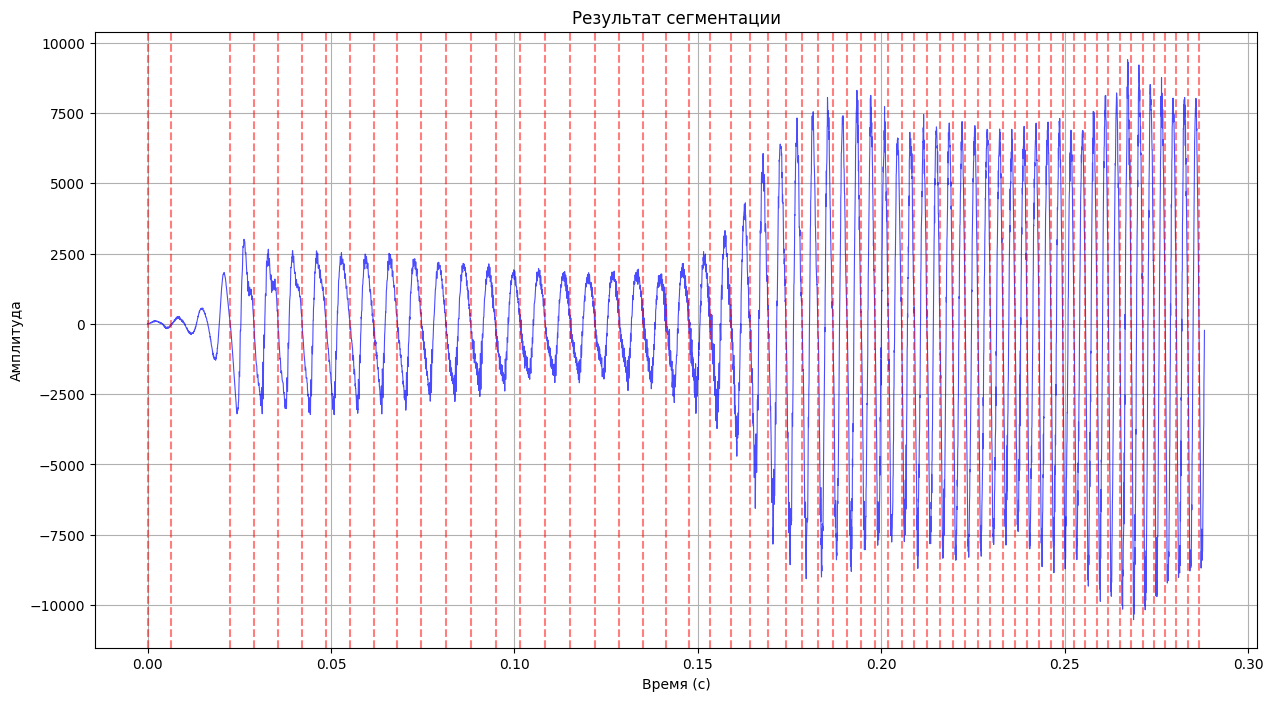

In [36]:
visualize(data, boundaries, fs)

Добавим новое условие - нам нужны не просто точки перехода через ноль, а точки перехода из отрицательных значений в положительные

In [37]:
def segment_with_zero_crossings_from_neg_to_pos(audio, fs, frame_size=0.02, hop_size=0.01, min_f0=50, max_f0=600):
    """
    Сегментация аудио на периоды основного тона

    """
    # Центрируем сигнал (убираем постоянную составляющую)
    audio = audio - np.mean(audio)

    frame_length = int(frame_size * fs)
    hop_length = int(hop_size * fs)

    boundaries = [0]  # Считаем, что первая граница в нуле
    periods = []

    # Переходы через ноль в положительную область в сигнале
    zero_crossings = np.where((np.sign(audio[:-1]) == -1) & (np.sign(audio[1:]) == 1))[0]

    # Добавим нули в конец сигнала, чтобы разметить периоды в последнем окне
    audio = np.concatenate((audio, np.zeros(int(frame_size * fs))))

    pos = 0
    while pos + frame_length < len(audio):
        frame = audio[pos:pos + frame_length]

        # Находим период в текущем фрейме
        period = find_pitch_period(frame, fs//max_f0, fs//min_f0)

        if period > 0:
            # Если нашли период, добавляем границу
            new_pos = pos + period
            if new_pos < len(audio) and new_pos > boundaries[-1]:
                new_pos_corrected = nearest(zero_crossings, new_pos)
                boundaries.append(int(new_pos_corrected))
                periods.append(period)
                pos = new_pos_corrected  # Переходим к следующему периоду
            else:
                pos += hop_length
        else:
            # Если не нашли период (пауза или шум), двигаемся с заданным шагом
            pos += hop_length

    # Добавляем конец сигнала как последнюю границу
    if boundaries[-1] < len(audio):
        boundaries.append(len(audio))

    return np.array(boundaries), np.array(periods)

In [38]:
boundaries, periods = segment_with_zero_crossings_from_neg_to_pos(data, fs, frame_size=0.01, hop_size=0.005)

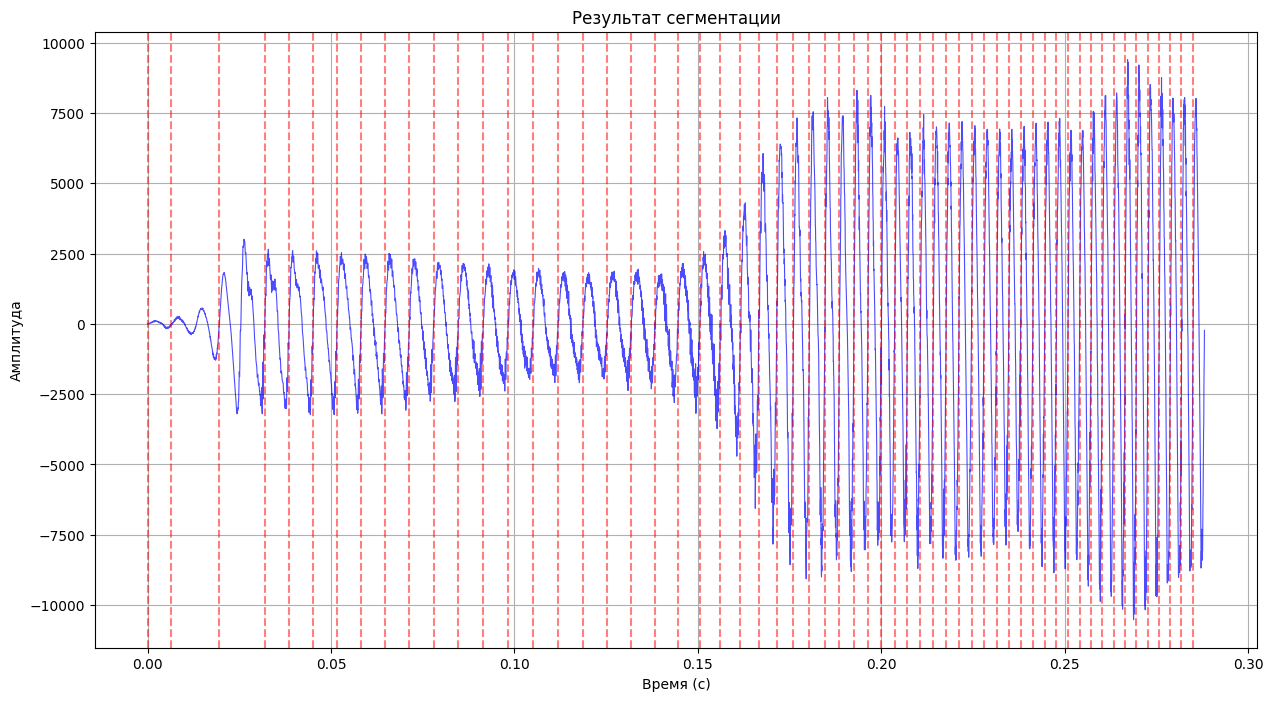

In [39]:
visualize(data, boundaries, fs)

Задание. <br/>Реализуйте запись результата сегментации в seg-файл. Добавьте варианты сегментации с помощью поиска ЧОТ кепстральным методом и методом YIN. Пусть результаты сегментации разными методами будут записаны на разные уровни seg-файла. Сравните результат.